# Sales Forecasting Project

## 1. Introduction

This project aims to predict the sales of a company based on advertising spending across three media channels: TV, Radio, and Newspaper. Using machine learning models such as Linear Regression and Random Forest, we seek to understand how each advertising channel contributes to overall sales and develop an accurate sales forecast.

Initially, the analysis will be performed on the original dataset. Later, a new variable, **"Internet Ad Budget"**, will be added to simulate how online advertising could influence sales, providing a more contemporary analysis of ad spending. The addition of this variable is intended as an extra study but considers realistic scenarios where companies would invest in internet advertising.

At the end of the project, we will compare the results of the original analysis to the adjusted model that includes the new variable.

## Table of contents

1. **Introduction**
2. **Data Preprocessing**
3. **Exploratory Data Analysis (EDA)**
4. **Model Training and Evaluation** (Original Dataset)
5. **Feature Importance and Model Comparison**
6. **Adding Internet Ad Budget Analysis**
7. **Conclusions**

## 2. Libraries and Data Loading 

In [1]:
# Data analysis and manipulation libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.model_selection import cross_val_score

In [2]:
# Load the dataset from the local directory
data = pd.read_csv('../data/advertising_budget_and_sales.csv', index_col=0)

# Optionally rename columns
data.columns = ['TV Ad Budget', 'Radio Ad Budget', 'Newspaper Ad Budget', 'Sales']

# Display the first few rows of the dataset
print(data.head())
print(data.columns)

   TV Ad Budget  Radio Ad Budget  Newspaper Ad Budget  Sales
1         230.1             37.8                 69.2   22.1
2          44.5             39.3                 45.1   10.4
3          17.2             45.9                 69.3    9.3
4         151.5             41.3                 58.5   18.5
5         180.8             10.8                 58.4   12.9
Index(['TV Ad Budget', 'Radio Ad Budget', 'Newspaper Ad Budget', 'Sales'], dtype='object')


- Brief Description of Datset:
    - TV Ad Budget, Radio Ad Budget, Newspaper Ad Budget, and Sales columns.
    - Note: A new variable, Internet Ad Budget, will be added to reflect modern advertising strategies.


## 3. Data Exploration and Cleaning

### 3.1 Basic Data Information

In [3]:
# Checking for missing values and data types
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TV Ad Budget         200 non-null    float64
 1   Radio Ad Budget      200 non-null    float64
 2   Newspaper Ad Budget  200 non-null    float64
 3   Sales                200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


,TV Ad Budget,Radio Ad Budget,Newspaper Ad Budget,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


### 3.2 Exploratory Data Analysis (EDA)

To better understand the relationships between the different types of advertising budgets and sales, we first analyze the correlation between these variables.

- Correlation Matrix (Heatmap):
We use a heatmap to display the correlation values between the variables. The correlation ranges from -1 to 1:

- 1 indicates a perfect positive correlation (as one variable increases, the other also increases).
- -1 indicates a perfect negative correlation (as one variable increases, the other decreases).
- 0 indicates no correlation.

<function matplotlib.pyplot.show(close=None, block=None)>

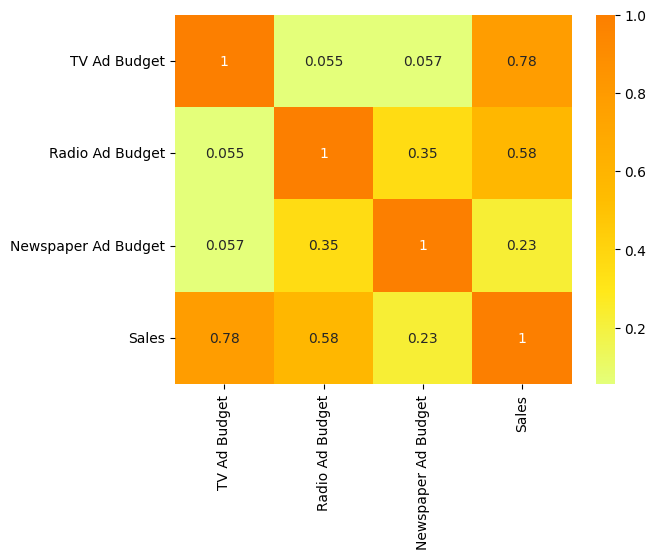

In [4]:
# Heatmap of correlations
sns.heatmap(data.corr(), cmap= 'Wistia', annot= True)
plt.show

From the heatmap, we observe the following:

TV Ad Budget shows a strong positive correlation with Sales.
Radio Ad Budget has a moderate positive correlation with Sales.
Newspaper Ad Budget has a weak correlation with Sales.


- Scatter Plots:
We use scatter plots to visualize the relationship between each advertising budget and sales:

- TV Ad Budget vs Sales: There is a clear upward trend, indicating that higher TV ad spending is linked to higher sales.
- Radio Ad Budget vs Sales: While there is a positive relationship, it's less pronounced compared to TV ads.
- Newspaper Ad Budget vs Sales: The plot shows less of a clear relationship, confirming the weak correlation.

This visual exploration gives us an initial understanding of how the advertising channels relate to sales, which will inform our modeling decisions.

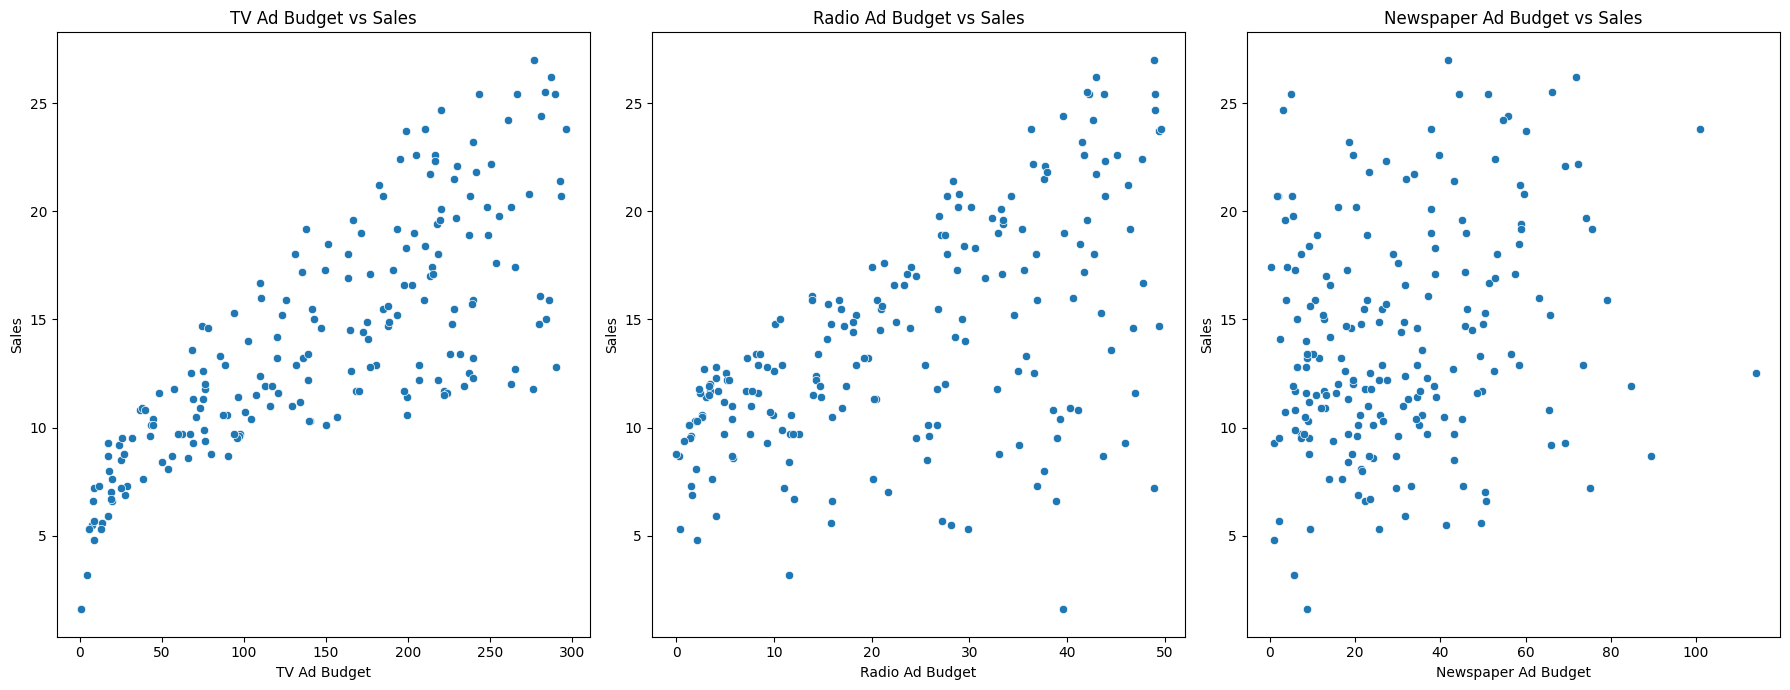

In [5]:
# Creating scatter plots to explore relationships between ad budgets and sales
plt.figure(figsize=(18, 7))

# Scatter plot for TV Ad Budget vs Sales
plt.subplot(1, 3, 1)
sns.scatterplot(x=data['TV Ad Budget'], y=data['Sales'])
plt.title('TV Ad Budget vs Sales')

# Scatter plot for Radio Ad Budget vs Sales
plt.subplot(1, 3, 2)
sns.scatterplot(x=data['Radio Ad Budget'], y=data['Sales'])
plt.title('Radio Ad Budget vs Sales')

# Scatter plot for Newspaper Ad Budget vs Sales
plt.subplot(1, 3, 3)
sns.scatterplot(x=data['Newspaper Ad Budget'], y=data['Sales'])
plt.title('Newspaper Ad Budget vs Sales')

# Adjusting the layout to fit the plots
plt.tight_layout()
plt.show()

## 4. Data Distribution and Model Preparation

In this section, we prepare the data for model training and evaluation. Before building the machine learning models, we ensure the data is clean and ready for use, and that we understand the distribution of the key features.

1. Feature Distribution:

- To gain insights into the distribution of the advertising budgets, we use histograms to plot the distributions for TV, Radio, and Newspaper Ad Budgets.

- Observations:
    - TV Ad Budget: Most values are concentrated around a certain range, suggesting that this ad budget remains relatively consistent.
    - Radio Ad Budget: The distribution shows more variation, implying that spending on radio ads is more varied.
    - Newspaper Ad Budget: The budget for newspaper ads is generally lower, with fewer high outliers.

2.  Handling Missing or Outlier Data:

- At this point, we inspect the data for missing values or outliers. If there are any, we either impute or remove them to maintain the integrity of the dataset.

- Observations:
    - The dataset is clean, with no missing values or significant outliers that could disrupt model performance.

3. Splitting the Data:

    - We split the dataset into training and testing sets using an 80/20 ratio.
        - Training set: 80% of the data used to train the model.
        - Testing set: 20% of the data reserved for model evaluation.
        - We ensure that the splitting is done randomly to avoid any bias in the model's learning process.

4. Defining Features and Target:

- Features (X): The advertising budgets for TV, Radio, and Newspaper.
- Target (y): Sales, which we aim to predict.
- We drop the Sales column from the features to avoid data leakage during training.

In [6]:
# Define features (X) and target variable (y)

y = data['Sales']
X = data.drop('Sales', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### 4.1 Model Selection

We chose Linear Regression and Random Forest to predict sales based on advertising budgets. Both models are well-suited for regression problems but operate differently.

1. Linear Regression:
- Linear Regression is a simple model that assumes a linear relationship between the features (TV, Radio, Newspaper budgets) and the target (Sales).
- It works well when the relationship between the variables is linear, and we use it to establish a baseline performance.

Why this model?
- Linear Regression: It's simple, interpretable, and fast, making it a great starting point for regression tasks.

2. Random Forest:
- Random Forest is an ensemble model that creates multiple decision trees on random subsets of the data and averages their predictions.
- This model is often better at capturing complex, non-linear relationships and can provide insights into feature importance.

Why this model?
- Random Forest: It's robust against overfitting and can handle more complex relationships between the input features and target variable.

In [7]:
# Create regression models
linear_model = LinearRegression()
random_forest_model = RandomForestRegressor()

# training the models
linear_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

RandomForestRegressor()

### 4.2 Model Predictions and Evaluation

In this section, we will make predictions using both the Linear Regression and Random Forest models and evaluate their performance using the R² score.

1. Making Predictions:
- After training the models on the training dataset, we use them to predict sales on the test dataset.
- This allows us to see how well the models generalize to unseen data.

2. Evaluating the Models:

- We use the R² score (coefficient of determination) to evaluate the models' performance. The R² score indicates how well the independent variables explain the variance of the dependent variable.
- An R² score of 1.0 indicates a perfect fit, while a score of 0 indicates that the model does not explain any of the variability in the target variable.
- We will compute the R² score for both models on the test set.

In [8]:
# Make predictions
linear_predictions = linear_model.predict(X_test)
rf_predictions = random_forest_model.predict(X_test)

# Evaluate the models
print("R^2 Score (Linear Regression):", metrics.r2_score(y_test, linear_predictions))
print("R^2 Score (Random Forest):", metrics.r2_score(y_test, rf_predictions)) 

R^2 Score (Linear Regression): 0.8609466508230368
R^2 Score (Random Forest): 0.9824196666435733


### 4.3 Results

1. The R² scores for each model are as follows:
- R² Score (Linear Regression): 0.8609
- R² Score (Random Forest): 0.9824
- These scores provide insight into how well each model predicts sales based on advertising budgets.

2. Interpretation of R² scores:

- The Linear Regression model has an R² score of 0.8609, indicating that approximately 86.09% of the variance in sales is explained by the model. While this is a good score, there may be room for improvement.
- The Random Forest model has an R² score of 0.9824, indicating that it explains approximately 98.24% of the variance in sales, showcasing its effectiveness in capturing complex relationships in the data.

  
3. Conclusion:

- By comparing the R² scores of the two models, we can determine that the Random Forest model outperforms the Linear Regression model in predicting sales.
- Additionally, this evaluation will help in understanding the effectiveness of the features used in the model and their contribution to predicting the target variable.

## 5. Visualization of Actual vs Predicted Sales

To further understand the performance of our models, we will visualize the actual sales versus the predicted sales from both models using a line plot. This will allow us to see how closely the predictions align with the actual sales data.

1. Preparing the Data for Visualization:
- We will create a DataFrame to hold the actual sales and the predicted sales from both models.

2. Creating the Line Plot:

- We will use Seaborn's lineplot to visualize the actual sales and the predictions from both models.
- This visual comparison will help us assess the accuracy and performance of the models.

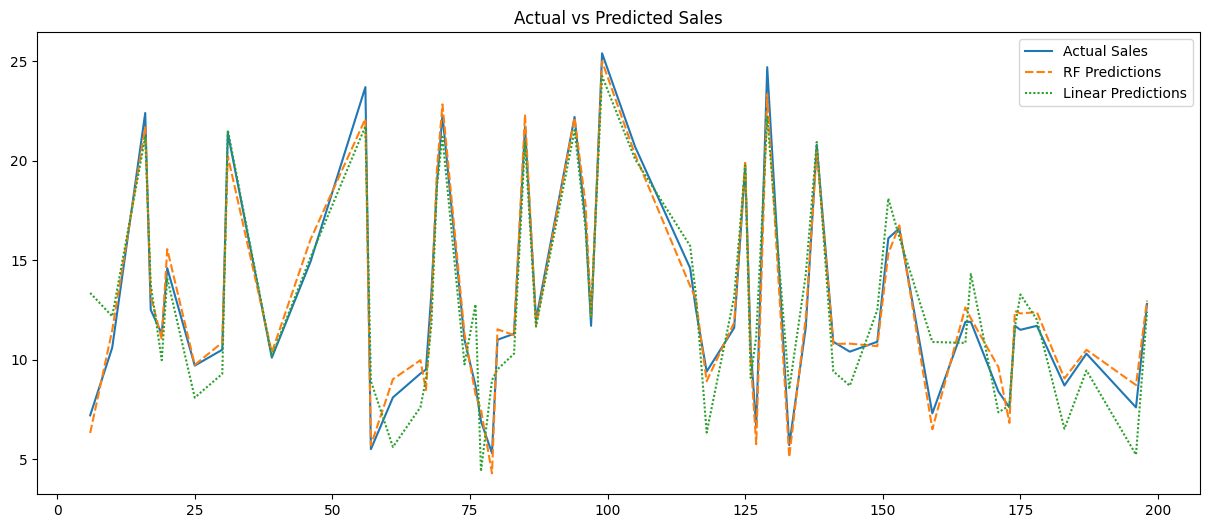

In [9]:
# Create a comparison DataFrame for predictions
comparison_df = pd.DataFrame()
comparison_df["Actual Sales"] = y_test
comparison_df["RF Predictions"] = rf_predictions
comparison_df["Linear Predictions"] = linear_predictions

# Visualize the predictions
plt.figure(figsize=(15, 6))
sns.lineplot(data=comparison_df)
plt.title('Actual vs Predicted Sales')
plt.show()

3. Interpreting the Visualization:

- The line plot displays the actual sales data along with the predictions from both the Random Forest and Linear Regression models.
- A good model will show its predictions closely following the actual sales line.
- Observing the distance between the predicted lines and the actual sales line can give insights into the models' performance and any potential areas for improvement.

4. Conclusion:

- This visualization reinforces the evaluation metrics obtained earlier by providing a visual representation of the model predictions.
- It highlights the strengths of the Random Forest model in capturing the trends in the sales data compared to the Linear Regression model.

#### Comparative Chart

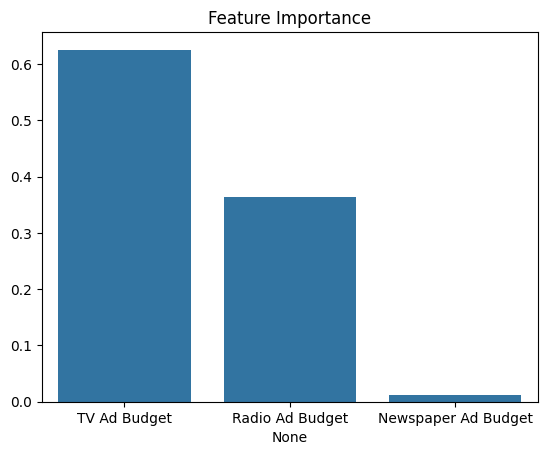

In [10]:
# Feature importance for Random Forest model
sns.barplot(x=X.columns, y=random_forest_model.feature_importances_)
plt.title('Feature Importance')
plt.show()

# Sales Forecasting Project - Adding a New Feature

In this section, we introduce the new variable, "Internet Ad Budget," and assess its impact on sales. The addition of this variable allows us to model the effect of internet advertising, which has become increasingly important in modern marketing strategies.

## 1. Load the Dataset

First, we load the original dataset containing the advertising budgets and sales.

1. Create the Internet Ad Budget Variable

- We create the "Internet Ad Budget" as the average of the "TV Ad Budget" and "Radio Ad Budget" to ensure it is comparable to the existing data.

2. Reorganize Columns
- To maintain clarity, we reorganize the dataset columns to position "Internet Ad Budget" before "Sales."

3. Adjust Sales Calculation

We define an impact factor for the Internet and calculate the adjusted sales based on this new variable.

4. Visualizing the New Sales

We visualize the first few entries of the dataset, focusing on the "Internet Ad Budget" and "Adjusted Sales."

In [11]:
# Load the dataset
data = pd.read_csv('../data/advertising_budget_and_sales.csv', index_col=0)

In [12]:
# Create 'Internet Ad Budget' as the average of 'TV Ad Budget' and 'Radio Ad Budget'
data['Internet Ad Budget ($)'] = (data['TV Ad Budget ($)'] + data['Radio Ad Budget ($)']) / 2

# Reorganizing columns to put 'Internet Ad Budget ($)' before 'Sales ($)'
data = data[['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)', 'Internet Ad Budget ($)', 'Sales ($)']]

# Optionally rename columns
data.columns = ['TV Ad Budget', 'Radio Ad Budget', 'Newspaper Ad Budget', 'Internet Ad Budget', 'Sales']

# Display the first few rows of the dataset
print(data.head())
print(data.columns)

   TV Ad Budget  Radio Ad Budget  Newspaper Ad Budget  Internet Ad Budget  \
1         230.1             37.8                 69.2              133.95   
2          44.5             39.3                 45.1               41.90   
3          17.2             45.9                 69.3               31.55   
4         151.5             41.3                 58.5               96.40   
5         180.8             10.8                 58.4               95.80   

   Sales  
1   22.1  
2   10.4  
3    9.3  
4   18.5  
5   12.9  
Index(['TV Ad Budget', 'Radio Ad Budget', 'Newspaper Ad Budget',
       'Internet Ad Budget', 'Sales'],
      dtype='object')


In [13]:
# Define an impact factor for the Internet
impact_factor = 0.1  # por exemplo, cada dólar investido em Internet aumenta as vendas em $0.5

# Calculate new sales based on the Internet ad budget
data['Adjusted Sales'] = data['Sales'] + (data['Internet Ad Budget'] * impact_factor)

In [14]:
# Drop the original 'Sales' column to avoid confusion in the analysis
data = data.drop('Sales', axis=1)

In [15]:
# Visualizando as novas vendas
print(data[['Internet Ad Budget', 'Adjusted Sales']].head(10))

    Internet Ad Budget  Adjusted Sales
1               133.95          35.495
2                41.90          14.590
3                31.55          12.455
4                96.40          28.140
5                95.80          22.480
6                28.80          10.080
7                45.15          16.315
8                69.90          20.190
9                 5.35           5.335
10              101.20          20.720


## 2. Model Preparation

We set up our features and target variable, split the dataset into training and testing sets, and create the Linear Regression and Random Forest models.

In [16]:
# Define features (X) and target variable (y)
y = data['Adjusted Sales']
X = data.drop('Adjusted Sales', axis=1)

In [17]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [18]:
# Creating the models
linear_model = LinearRegression()
random_forest_model = RandomForestRegressor()

# Training the models
linear_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

RandomForestRegressor()

## 3. Making Predictions and Evaluating Models

We make predictions with both models and evaluate their performance using the R² score.

In [19]:
# Making predictions
predictions_linear = linear_model.predict(X_test)
predictions_random_forest = random_forest_model.predict(X_test)

In [20]:
# Evaluating the models
print("R^2 Score (Linear Regression):", metrics.r2_score(y_test, predictions_linear))
print("R^2 Score (Random Forest):", metrics.r2_score(y_test, predictions_random_forest))

R^2 Score (Linear Regression): 0.9566459358700672
R^2 Score (Random Forest): 0.9891610107333071


## 4. Visualizing Predictions

We prepare an auxiliary DataFrame for visualizing actual vs. predicted adjusted sales.

In [21]:
# Preparing the auxiliary DataFrame for visualization
auxiliary_table = pd.DataFrame()
auxiliary_table["Actual Sales"] = y_test
auxiliary_table["Adjusted Sales"] = data.loc[y_test.index, 'Adjusted Sales']  # Incluindo Adjusted Sales
auxiliary_table["Predictions (Random Forest)"] = predictions_random_forest
auxiliary_table["Predictions (Linear Regression)"] = predictions_linear

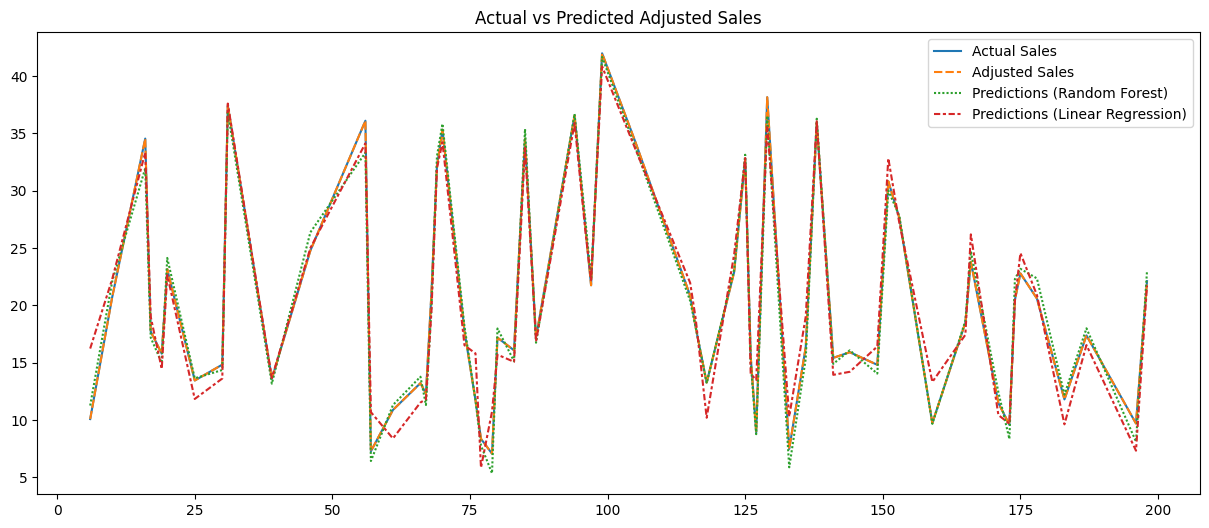

In [22]:
# Visualizing the predictions
plt.figure(figsize=(15, 6))
sns.lineplot(data=auxiliary_table)
plt.title('Actual vs Predicted Adjusted Sales')
plt.show()

### 4.1 Feature Importance

To understand the contributions of each feature in the Random Forest model, we analyze feature importance.

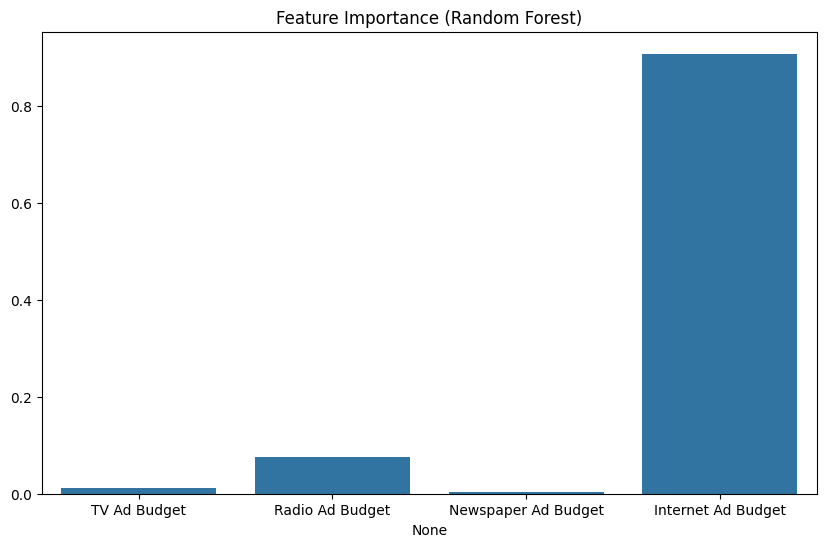

In [23]:
# Feature importance from Random Forest
plt.figure(figsize=(10, 6))
sns.barplot(x=X.columns, y=random_forest_model.feature_importances_)
plt.title('Feature Importance (Random Forest)')
plt.show()

### 4.2 Correlation Analysis

We calculate and visualize the correlation matrix to assess how the new variable correlates with the adjusted sales.

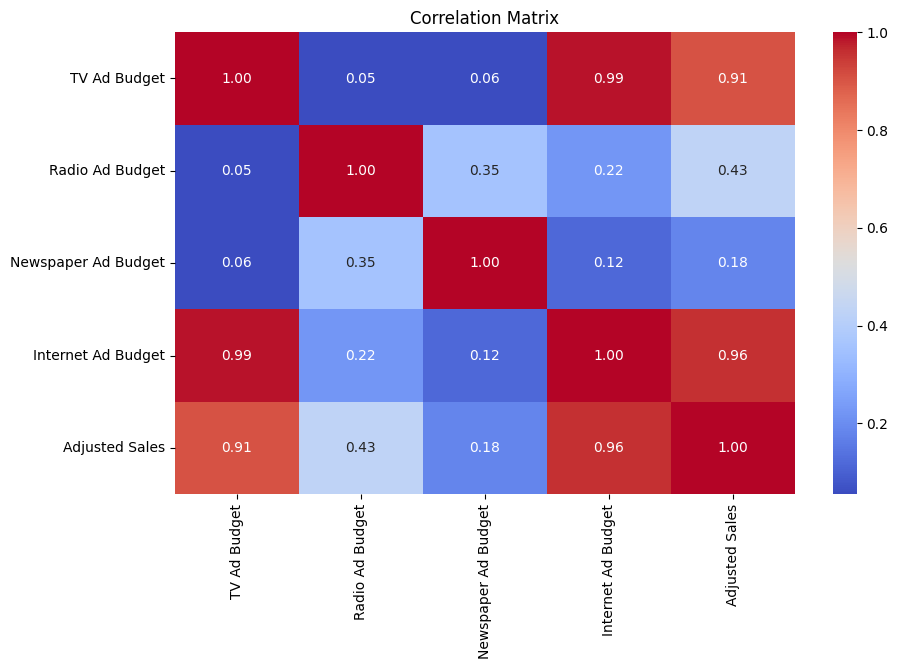

In [27]:
# Calculating the correlation matrix
correlation_matrix = data.corr()

# Creating a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### 4.3 Scatter Plot of Internet Ad Budget vs. Adjusted Sales

We visualize the relationship between the Internet Ad Budget and Adjusted Sales using a scatter plot.

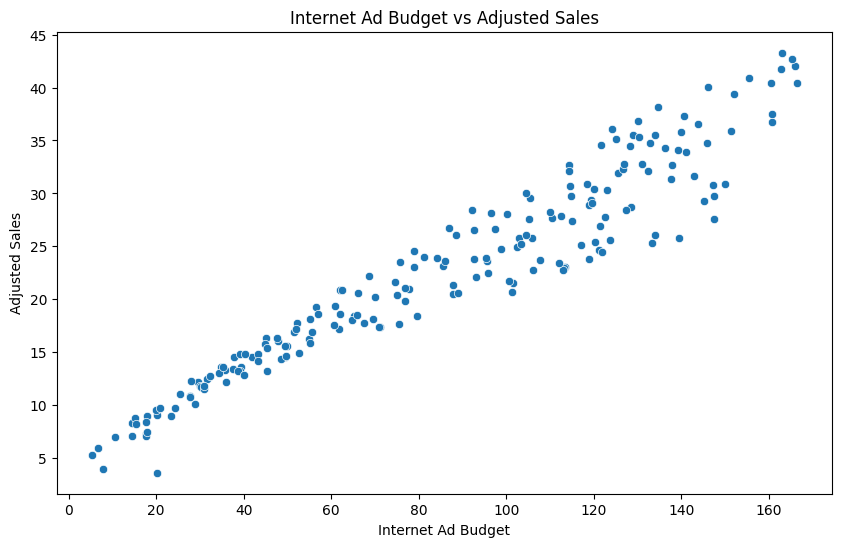

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Internet Ad Budget', y='Adjusted Sales')
plt.title('Internet Ad Budget vs Adjusted Sales')
plt.xlabel('Internet Ad Budget')
plt.ylabel('Adjusted Sales')
plt.show()

## 5. Model Performance Evaluation

Finally, we evaluate the performance of both models using training, testing, and cross-validation R² scores.

Linear Regression R² Score:
Training: 0.9697, Test: 0.9566
Cross-validation scores: [0.96373589 0.9733805  0.9784679  0.93867212 0.96856621]

Random Forest R² Score:
Training: 0.9982, Test: 0.9892
Cross-validation scores: [0.98930514 0.99136617 0.99145868 0.98130171 0.98393274]


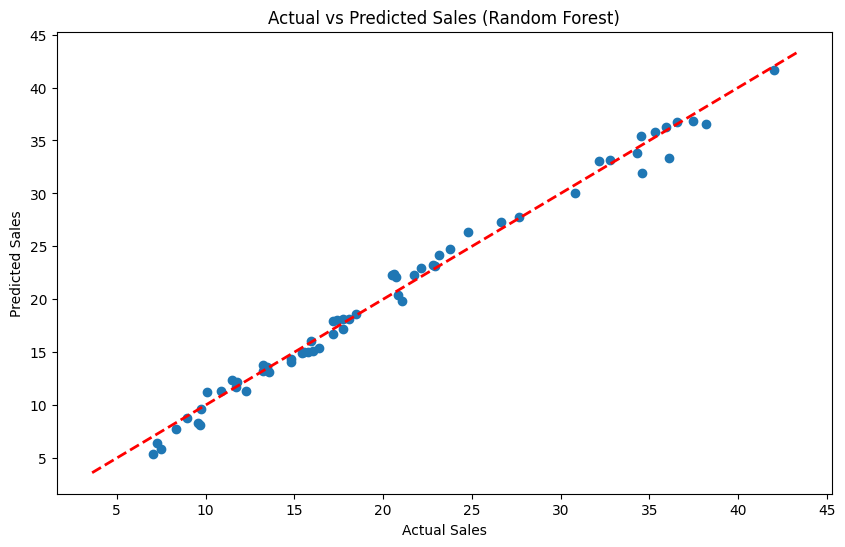

In [28]:
# Evaluating the performance of Linear Regression
linear_r2_train = linear_model.score(X_train, y_train)
linear_r2_test = linear_model.score(X_test, y_test)
linear_cv_scores = cross_val_score(linear_model, X, y, cv=5)

# Evaluating the performance of Random Forest
random_forest_r2_train = random_forest_model.score(X_train, y_train)
random_forest_r2_test = random_forest_model.score(X_test, y_test)
random_forest_cv_scores = cross_val_score(random_forest_model, X, y, cv=5)

# Results
print("Linear Regression R² Score:")
print(f"Training: {linear_r2_train:.4f}, Test: {linear_r2_test:.4f}")
print(f"Cross-validation scores: {linear_cv_scores}")

print("\nRandom Forest R² Score:")
print(f"Training: {random_forest_r2_train:.4f}, Test: {random_forest_r2_test:.4f}")
print(f"Cross-validation scores: {random_forest_cv_scores}")

# Visualizando Previsões vs Valores Reais para Random Forest
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions_random_forest)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales (Random Forest)')
plt.show()